PART 1 Assessing Models with Alternative Data                

Step 3. Replication

In [1]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218909 sha256=cfc52b1c910f1dc31deccd8a2cf6d73137edfda92f83247810f00131079d796a
  Stored in directory: /root/.cache/pip/wheels/7f/33/8b/50b245c5c65433cd8f5cb24ac15d97e5a3db2d41a8b6ae957d
Successfully built pandas_ta


In [2]:
!pip install matplotlib

In [3]:
!pip install flask

In [43]:
!pip install gunicorn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.1 MB/s eta 0:00:00


Step 3(b).

Download its data.



In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

# Step 1: Download the Data
# Define the ticker symbol and time frame
ticker = "ECH"
start_date = "2009-12-12"
end_date = "2020-01-01"

# Download historical data
data = yf.download(ticker, start=start_date, end=end_date)

# Save the raw data to a CSV file
data.to_csv("ECH_historical_data.csv")
print("Raw data downloaded and saved to ECH_historical_data.csv")

# Step 2: Clean the Data
# Drop rows with missing values (if any)
data.dropna(inplace=True)

# Flatten multi-level column names
data.columns = data.columns.droplevel(1)

# Step 3: Normalize the Data
# Min-max normalization function
def min_max_normalize(column):
    return (column - column.min()) / (column.max() - column.min())

# Check the column names in the dataset
print("Column names in the dataset:", data.columns.tolist())

# Normalize the numerical columns (Open, High, Low, Close, Adj Close, Volume)
# Ensure the column names match the dataset
data_normalized = data.copy()
columns_to_normalize = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

# Filter out columns that don't exist in the dataset
columns_to_normalize = [col for col in columns_to_normalize if col in data_normalized.columns]

# Apply normalization to the selected columns
data_normalized[columns_to_normalize] = data_normalized[columns_to_normalize].apply(min_max_normalize)

# Step 4: Prepare the Target Variable
# Create the binary classification variable Γ(t)
data_normalized["Gamma"] = np.where(
    data_normalized["Open"].shift(-1) > data_normalized["Open"], 1, -1
)

# Drop the last row since Γ(t) for the last day cannot be calculated
data_normalized.dropna(subset=["Gamma"], inplace=True)

# Step 5: Save the Preprocessed Data
data_normalized.to_csv("ECH_preprocessed_data.csv")
print("Preprocessed data saved to ECH_preprocessed_data.csv")

[*********************100%***********************]  1 of 1 completed

Raw data downloaded and saved to ECH_historical_data.csv
Column names in the dataset: ['Close', 'High', 'Low', 'Open', 'Volume']
Preprocessed data saved to ECH_preprocessed_data.csv


In [5]:
import pandas as pd

# Load the preprocessed data
data_normalized = pd.read_csv("ECH_preprocessed_data.csv", index_col=0)

# Display the first 10 rows of the table
print(data_normalized.head(10))

               Close      High       Low      Open    Volume  Gamma
Date                                                               
2009-12-14  0.453346  0.454779  0.497858  0.448796  0.095145      1
2009-12-15  0.449461  0.450883  0.504424  0.451845  0.048906      1
2009-12-16  0.450687  0.459496  0.505362  0.467086  0.089609     -1
2009-12-17  0.446599  0.445550  0.492230  0.439448  0.023376      1
2009-12-18  0.450279  0.449447  0.490353  0.457129  0.040088     -1
2009-12-21  0.454572  0.451908  0.499921  0.450828  0.014354      1
2009-12-22  0.443187  0.449749  0.500354  0.457428  0.106423     -1
2009-12-23  0.447495  0.446662  0.495836  0.454369  0.005639      1
2009-12-24  0.449341  0.452424  0.506190  0.460079  0.040139     -1
2009-12-28  0.456316  0.456746  0.508072  0.456816  0.010612      1


[*********************100%***********************]  1 of 1 completed


Raw data downloaded and saved to ECH_historical_data.csv
Preprocessed data saved to ECH_preprocessed_data.csv


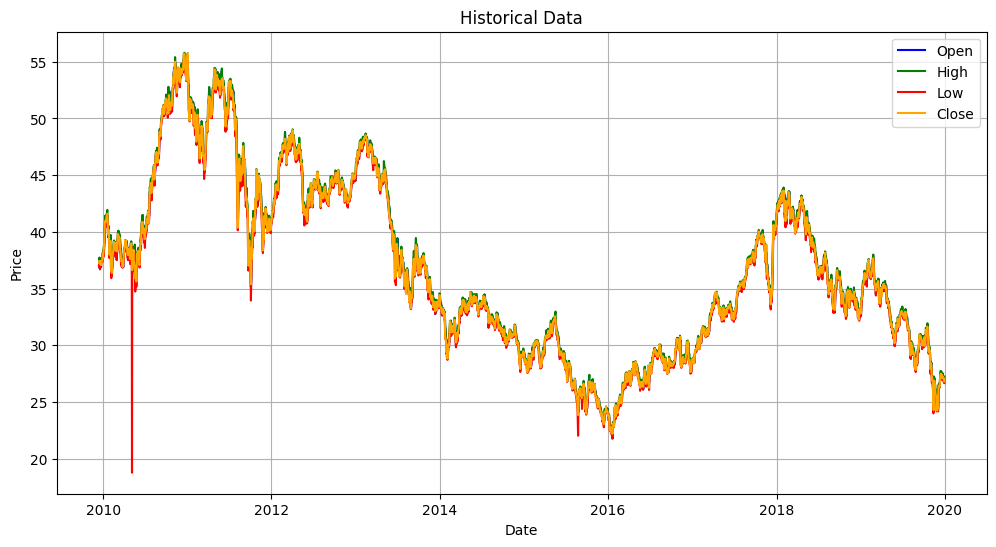

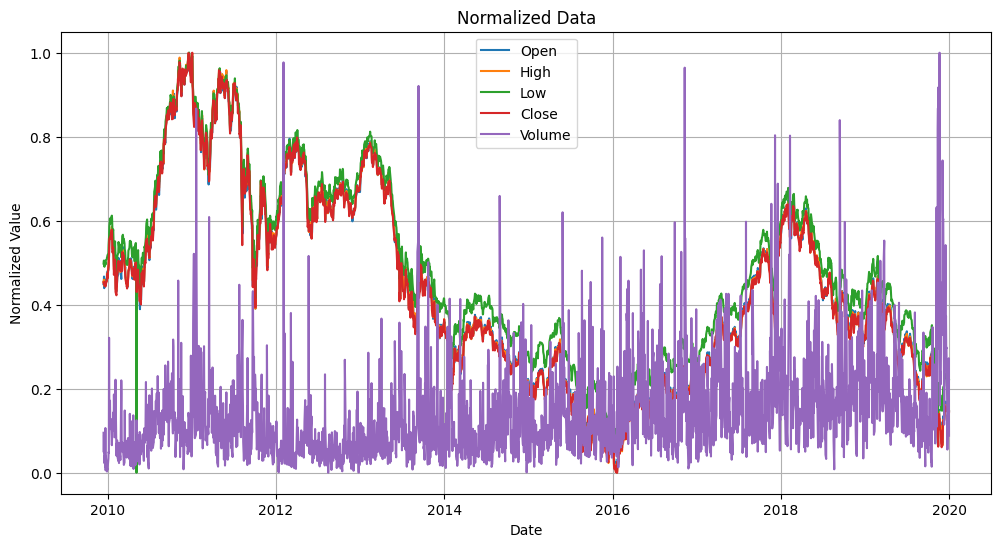

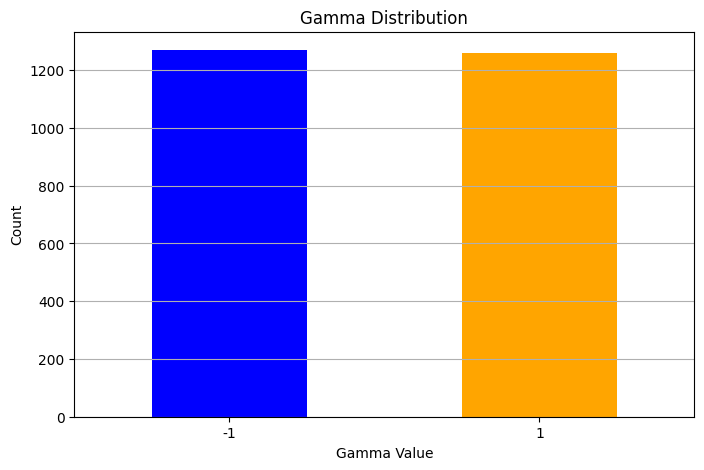

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Download the Data
ticker = "ECH"
start_date = "2009-12-12"
end_date = "2020-01-01"

# Download historical data
data = yf.download(ticker, start=start_date, end=end_date)

# Save the raw data to a CSV file
data.to_csv("ECH_historical_data.csv")
print("Raw data downloaded and saved to ECH_historical_data.csv")

# Step 2: Clean the Data
data.dropna(inplace=True)
data.columns = data.columns.droplevel(1)

# Step 3: Normalize the Data
def min_max_normalize(column):
    return (column - column.min()) / (column.max() - column.min())

# Check the column names
columns_to_normalize = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
columns_to_normalize = [col for col in columns_to_normalize if col in data.columns]

data_normalized = data.copy()
data_normalized[columns_to_normalize] = data_normalized[columns_to_normalize].apply(min_max_normalize)

# Step 4: Prepare the Target Variable
data_normalized["Gamma"] = np.where(
    data_normalized["Open"].shift(-1) > data_normalized["Open"], 1, -1
)
data_normalized.dropna(subset=["Gamma"], inplace=True)

# Save the preprocessed data
data_normalized.to_csv("ECH_preprocessed_data.csv")
print("Preprocessed data saved to ECH_preprocessed_data.csv")

# Step 6: Visualize the Data
# Plot 1: Historical Data (Raw)
plt.figure(figsize=(12, 6))
plt.plot(data.index, data["Open"], label="Open", color="blue")
plt.plot(data.index, data["High"], label="High", color="green")
plt.plot(data.index, data["Low"], label="Low", color="red")
plt.plot(data.index, data["Close"], label="Close", color="orange")
plt.title("Historical Data")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Normalized Data
plt.figure(figsize=(12, 6))
for col in columns_to_normalize:
    plt.plot(data_normalized.index, data_normalized[col], label=col)
plt.title("Normalized Data")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Gamma Distribution
plt.figure(figsize=(8, 5))
data_normalized["Gamma"].value_counts().plot(kind="bar", color=["blue", "orange"])
plt.title("Gamma Distribution")
plt.xlabel("Gamma Value")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["-1", "1"], rotation=0)
plt.grid(axis="y")
plt.show()

In [7]:
# Step 1: Install Pandas TA (if not already installed)
# Run this command in your terminal or notebook:
# !pip install pandas_ta

# Step 2: Load the Preprocessed Data
import pandas as pd

# Load the preprocessed data
data = pd.read_csv("ECH_preprocessed_data.csv", parse_dates=["Date"], index_col="Date")

# Step 3: Compute Technical Indicators Using Pandas TA
import pandas_ta as ta

# Add technical indicators to the dataset
data_with_indicators = data.copy()

# Example: Compute a few technical indicators
data_with_indicators.ta.rsi(length=14, append=True)  # Relative Strength Index (RSI)
data_with_indicators.ta.sma(length=20, append=True)  # Simple Moving Average (SMA)
data_with_indicators.ta.ema(length=20, append=True)  # Exponential Moving Average (EMA)
data_with_indicators.ta.bbands(length=20, append=True)  # Bollinger Bands
data_with_indicators.ta.macd(append=True)  # Moving Average Convergence Divergence (MACD)
data_with_indicators.ta.obv(append=True)  # On Balance Volume (OBV)
data_with_indicators.ta.stoch(append=True)  # Stochastic Oscillator
data_with_indicators.ta.atr(length=14, append=True)  # Average True Range (ATR)

# Step 4: Save the Enhanced Data
data_with_indicators.to_csv("ECH_data_with_indicators.csv")
print("Technical indicators computed and saved to ECH_data_with_indicators.csv")

Technical indicators computed and saved to ECH_data_with_indicators.csv


In [8]:
import pandas as pd

# Load the enhanced data with technical indicators
data_with_indicators = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Display the first 10 rows of the table
print(data_with_indicators.head(10))

               Close      High       Low      Open    Volume  Gamma  RSI_14  \
Date                                                                          
2009-12-14  0.453346  0.454779  0.497858  0.448796  0.095145      1     NaN   
2009-12-15  0.449461  0.450883  0.504424  0.451845  0.048906      1     NaN   
2009-12-16  0.450687  0.459496  0.505362  0.467086  0.089609     -1     NaN   
2009-12-17  0.446599  0.445550  0.492230  0.439448  0.023376      1     NaN   
2009-12-18  0.450279  0.449447  0.490353  0.457129  0.040088     -1     NaN   
2009-12-21  0.454572  0.451908  0.499921  0.450828  0.014354      1     NaN   
2009-12-22  0.443187  0.449749  0.500354  0.457428  0.106423     -1     NaN   
2009-12-23  0.447495  0.446662  0.495836  0.454369  0.005639      1     NaN   
2009-12-24  0.449341  0.452424  0.506190  0.460079  0.040139     -1     NaN   
2009-12-28  0.456316  0.456746  0.508072  0.456816  0.010612      1     NaN   

            SMA_20  EMA_20  BBL_20_2.0  ...  BBU_20

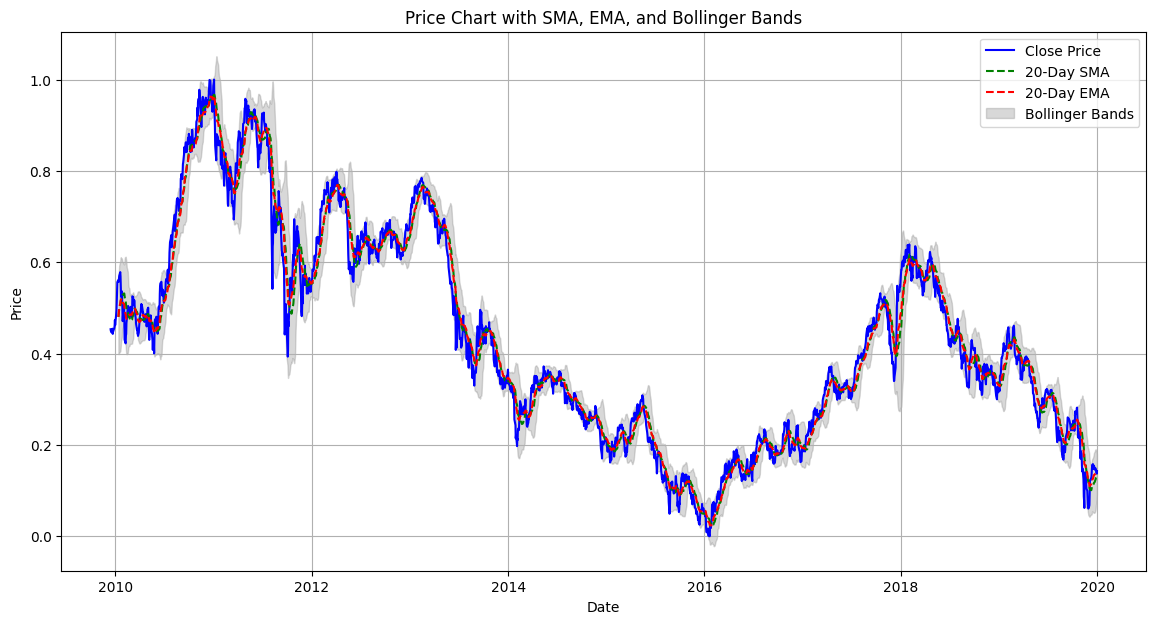

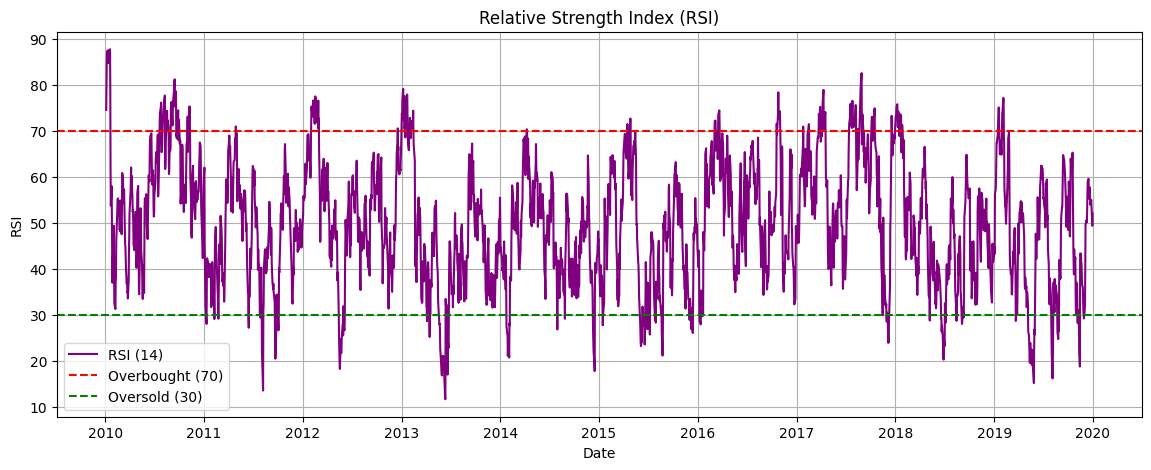

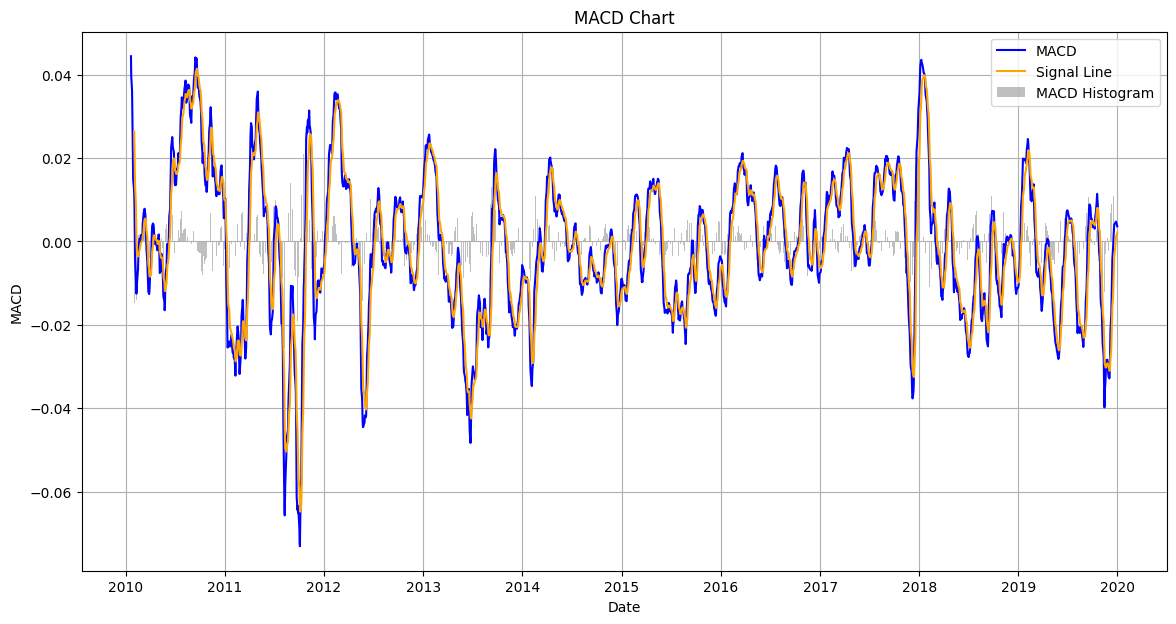

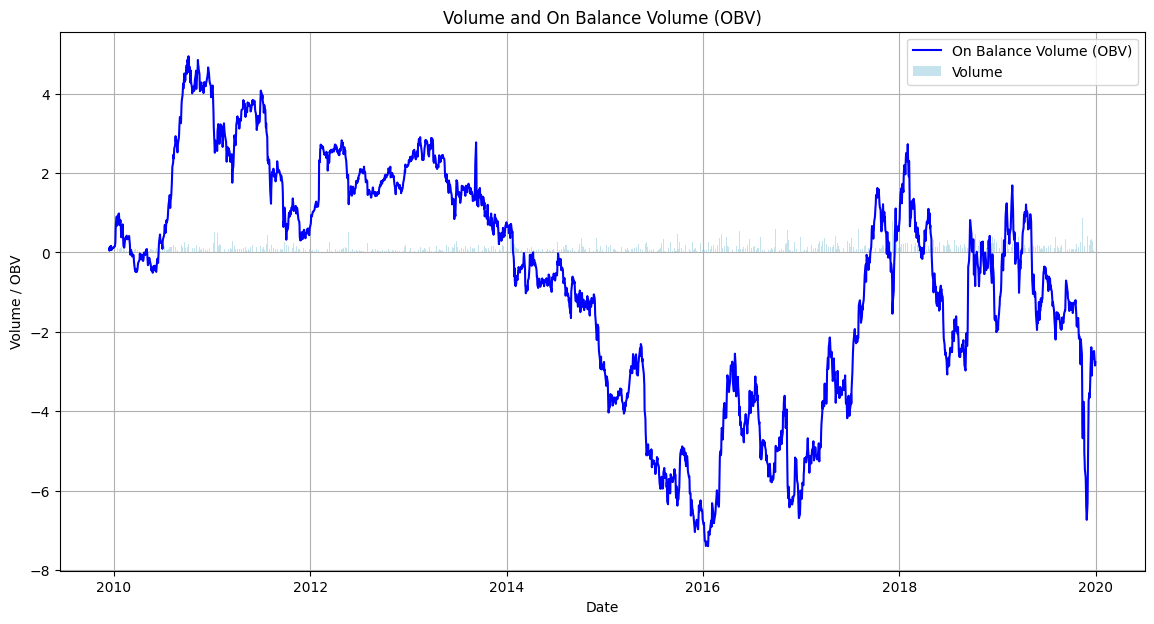

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data with indicators
data = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Plot 1: Price Chart with SMA, EMA, and Bollinger Bands
plt.figure(figsize=(14, 7))
plt.plot(data.index, data["Close"], label="Close Price", color="blue")
plt.plot(data.index, data["SMA_20"], label="20-Day SMA", color="green", linestyle="--")
plt.plot(data.index, data["EMA_20"], label="20-Day EMA", color="red", linestyle="--")
plt.fill_between(data.index, data["BBL_20_2.0"], data["BBU_20_2.0"], color="gray", alpha=0.3, label="Bollinger Bands")
plt.title("Price Chart with SMA, EMA, and Bollinger Bands")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

# Plot 2: RSI Chart
plt.figure(figsize=(14, 5))
plt.plot(data.index, data["RSI_14"], label="RSI (14)", color="purple")
plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
plt.title("Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.grid()
plt.show()

# Plot 3: MACD Chart
plt.figure(figsize=(14, 7))
plt.plot(data.index, data["MACD_12_26_9"], label="MACD", color="blue")
plt.plot(data.index, data["MACDs_12_26_9"], label="Signal Line", color="orange")
plt.bar(data.index, data["MACDh_12_26_9"], label="MACD Histogram", color="gray", alpha=0.5)
plt.title("MACD Chart")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.grid()
plt.show()

# Plot 4: Volume with OBV
plt.figure(figsize=(14, 7))
plt.bar(data.index, data["Volume"], label="Volume", color="lightblue", alpha=0.7)
plt.plot(data.index, data["OBV"], label="On Balance Volume (OBV)", color="blue")
plt.title("Volume and On Balance Volume (OBV)")
plt.xlabel("Date")
plt.ylabel("Volume / OBV")
plt.legend()
plt.grid()
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LassoCV
from sklearn.impute import SimpleImputer

# Step 1: Load the Enhanced Data
data = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Define the Target Variable
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable (Gamma)

# Step 3: Handle Missing Values
# Check for missing values in the dataset
print("Missing values in the dataset:")
print(X.isnull().sum())

# Impute missing values using the mean of each column
imputer = SimpleImputer(strategy="mean")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Step 4: Apply Feature Selection Techniques

# Technique 1: SelectKBest with Chi-Squared Test

# Shift data to make it non-negative for chi2
X_imputed_shifted = X_imputed - X_imputed.min().min()

# Chi-squared feature selection
selector_chi2 = SelectKBest(chi2, k=10)
X_chi2 = selector_chi2.fit_transform(X_imputed_shifted, y)
selected_features_chi2 = X.columns[selector_chi2.get_support()]

# ANOVA F-test feature selection
selector_f = SelectKBest(f_classif, k=10)
X_f = selector_f.fit_transform(X_imputed, y)
selected_features_f = X.columns[selector_f.get_support()]

# Tree-based feature selection
etc = ExtraTreesClassifier(n_estimators=100, random_state=42)
etc.fit(X_imputed, y)
importances = etc.feature_importances_
selected_features_tree = X.columns[np.argsort(importances)[-10:]]

# LASSO regression feature selection
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_imputed, y)
selected_features_lasso = X.columns[lasso.coef_ != 0]

# Combine selected features
selected_features = set(selected_features_chi2).union(
    set(selected_features_f),
    set(selected_features_tree),
    set(selected_features_lasso)
)

# Save selected features
selected_data = data[list(selected_features) + ["Gamma"]]
selected_data.to_csv("ECH_selected_features.csv")
print("Selected features saved to ECH_selected_features.csv")

Missing values in the dataset:
Close             0
High              0
Low               0
Open              0
Volume            0
RSI_14           14
SMA_20           19
EMA_20           19
BBL_20_2.0       19
BBM_20_2.0       19
BBU_20_2.0       19
BBB_20_2.0       19
BBP_20_2.0       19
MACD_12_26_9     25
MACDh_12_26_9    33
MACDs_12_26_9    33
OBV               0
STOCHk_14_3_3    15
STOCHd_14_3_3    17
ATRr_14          14
dtype: int64
Selected features saved to ECH_selected_features.csv


In [11]:
import pandas as pd

# Load the dataset with selected features
selected_data = pd.read_csv("ECH_selected_features.csv", parse_dates=["Date"], index_col="Date")

# Display the first 10 rows of the dataset
print(selected_data.head(10))

            SMA_20  MACD_12_26_9  BBB_20_2.0     Close  MACDs_12_26_9  \
Date                                                                    
2009-12-14     NaN           NaN         NaN  0.453346            NaN   
2009-12-15     NaN           NaN         NaN  0.449461            NaN   
2009-12-16     NaN           NaN         NaN  0.450687            NaN   
2009-12-17     NaN           NaN         NaN  0.446599            NaN   
2009-12-18     NaN           NaN         NaN  0.450279            NaN   
2009-12-21     NaN           NaN         NaN  0.454572            NaN   
2009-12-22     NaN           NaN         NaN  0.443187            NaN   
2009-12-23     NaN           NaN         NaN  0.447495            NaN   
2009-12-24     NaN           NaN         NaN  0.449341            NaN   
2009-12-28     NaN           NaN         NaN  0.456316            NaN   

            MACDh_12_26_9      Open       OBV  STOCHd_14_3_3  STOCHk_14_3_3  \
Date                                        

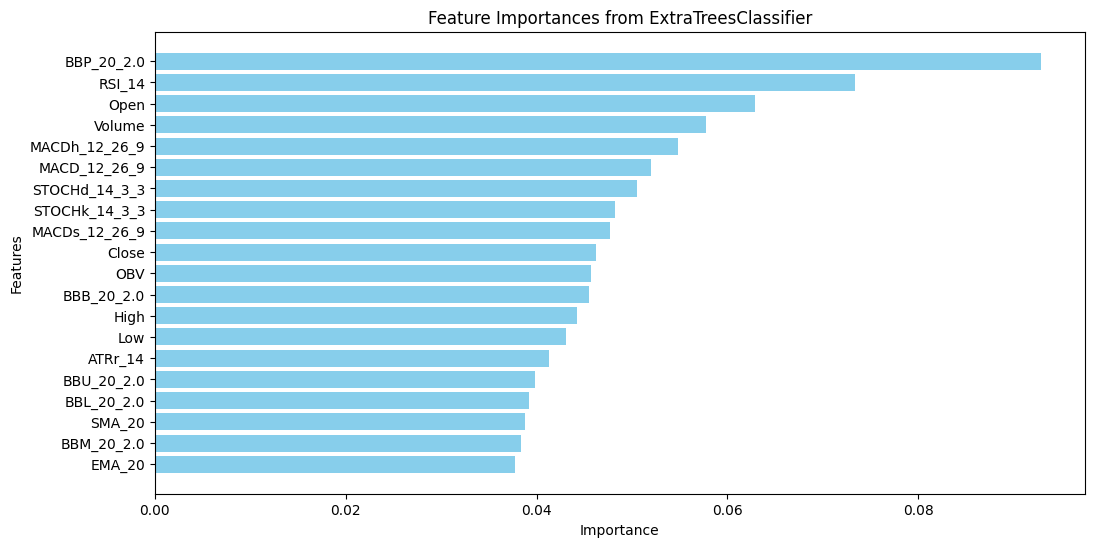

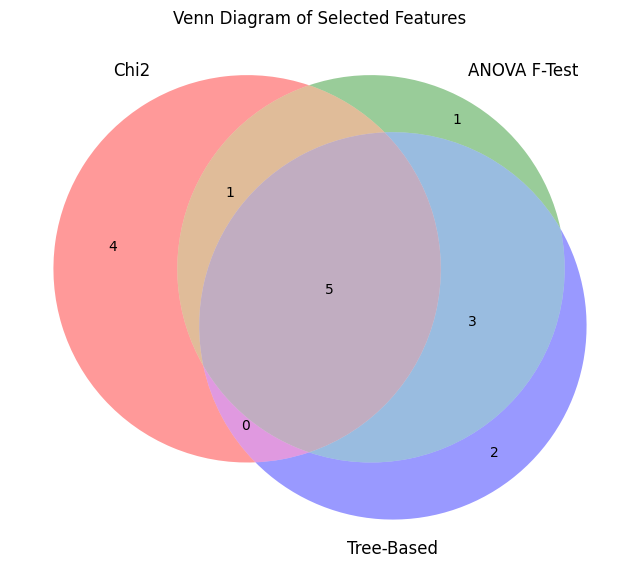

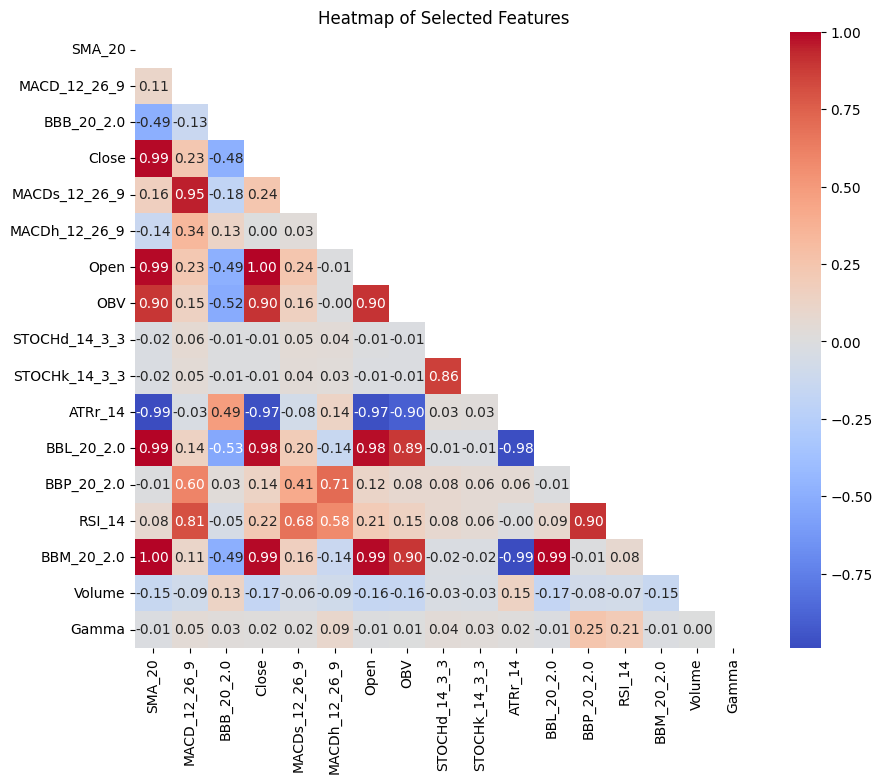

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3

# Load the selected features data
selected_features_data = pd.read_csv("ECH_selected_features.csv", parse_dates=["Date"], index_col="Date")

# Load original dataset
original_data = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Bar Plot for Feature Importances
def plot_feature_importances(importances, features, title):
    sorted_indices = np.argsort(importances)
    sorted_importances = importances[sorted_indices]
    # Fix: Ensure sorted_indices are within the bounds of features
    sorted_features = features[sorted_indices[-len(features):]]

    plt.figure(figsize=(12, 6))
    plt.barh(sorted_features, sorted_importances[-len(features):], color="skyblue")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.title(title)
    plt.show()

# Get feature importances and plot
# Fix: Use original_data.columns instead of X.columns
etc_importances = etc.feature_importances_
plot_feature_importances(etc_importances, original_data.drop(columns=['Gamma']).columns, "Feature Importances from ExtraTreesClassifier")

# Venn Diagram for Feature Selection Methods
venn_data = {
    "Chi2": set(selected_features_chi2),
    "ANOVA F-Test": set(selected_features_f),
    "Tree-Based": set(selected_features_tree),
    "LASSO": set(selected_features_lasso),
}

plt.figure(figsize=(8, 8))
venn = venn3(
    [venn_data["Chi2"], venn_data["ANOVA F-Test"], venn_data["Tree-Based"]],
    ("Chi2", "ANOVA F-Test", "Tree-Based"),
)
plt.title("Venn Diagram of Selected Features")
plt.show()

# Heatmap of Selected Features
plt.figure(figsize=(10, 8))
correlation_matrix = selected_features_data.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    mask=np.triu(correlation_matrix),
)
plt.title("Heatmap of Selected Features")
plt.show()

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Split the Data
X = data.drop(columns=["Gamma"])
y = data["Gamma"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Handle Missing Values
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Step 4: Scale the Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Step 5: Train the MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)
mlp.fit(X_train, y_train)

# Step 6: Evaluate the Model
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 71.74%
Classification Report:
              precision    recall  f1-score   support

          -1       0.74      0.75      0.75       281
           1       0.68      0.68      0.68       225

    accuracy                           0.72       506
   macro avg       0.71      0.71      0.71       506
weighted avg       0.72      0.72      0.72       506



In [14]:
import pandas as pd
from sklearn.metrics import classification_report

# Get the classification report in dictionary format
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the report to a DataFrame
report_df = pd.DataFrame(report).transpose()

# Display the table
print(report_df)

              precision    recall  f1-score     support
-1             0.742958  0.750890  0.746903  281.000000
1              0.684685  0.675556  0.680089  225.000000
accuracy       0.717391  0.717391  0.717391    0.717391
macro avg      0.713821  0.713223  0.713496  506.000000
weighted avg   0.717046  0.717391  0.717193  506.000000


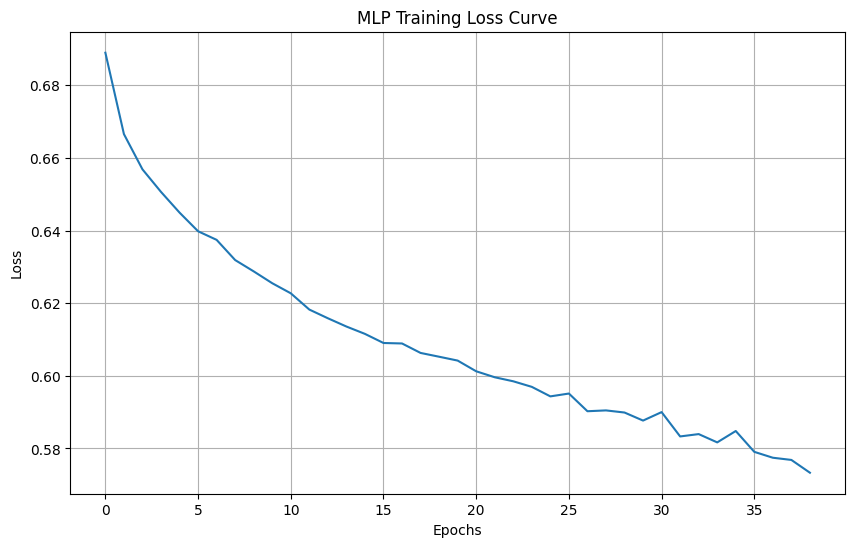

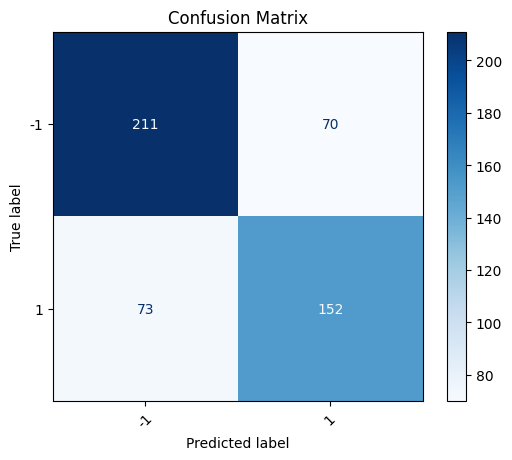

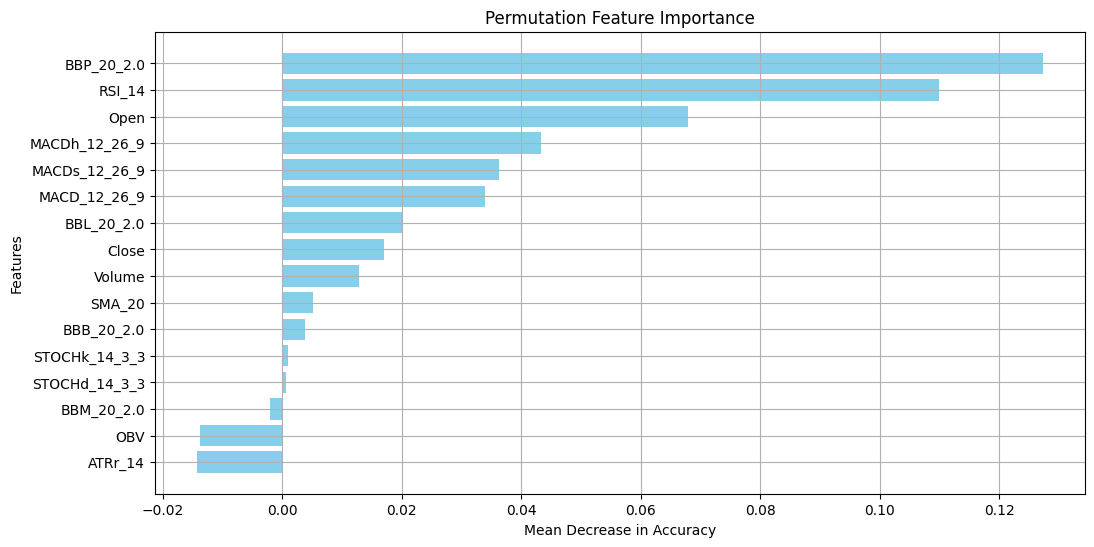

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.inspection import permutation_importance

# Step 1: Training Loss Curve
# Enable early_stopping to access the loss_curve_
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42,
    early_stopping=True  # Enable early stopping
)
mlp.fit(X_train, y_train) # Re-fit the model

plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

# Step 2: Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=np.unique(y_test))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Step 3: Feature Importance Approximation
perm_importance = permutation_importance(mlp, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(12, 6))
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx], color="skyblue")
plt.xlabel("Mean Decrease in Accuracy")
plt.ylabel("Features")
plt.title("Permutation Feature Importance")
plt.grid()
plt.show()

Step 3(c).

Pick 1 of the easier metrics (e.g. Correlation, or Dispersion ratio are easier than LASSO).

In [16]:
import pandas as pd

# Step 1: Load the Enhanced Data
data = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Calculate Correlation
# Compute the correlation between each feature and the target variable (Gamma)
correlation = data.corr()["Gamma"].abs().sort_values(ascending=False)

# Display the top 10 features with the highest correlation
print("Top 10 Features by Correlation with Gamma:")
print(correlation.head(10))

# Step 3: Select Top Features
# Select the top 10 features with the highest correlation
selected_features = correlation.index[1:11]  # Exclude Gamma (target variable)
print("\nSelected Features:")
print(selected_features)

# Step 4: Save the Selected Features
selected_data = data[selected_features].copy()
selected_data["Gamma"] = data["Gamma"]  # Add the target variable
selected_data.to_csv("ECH_selected_features_correlation.csv")
print("\nSelected features saved to ECH_selected_features_correlation.csv")

Top 10 Features by Correlation with Gamma:
Gamma            1.000000
BBP_20_2.0       0.251631
RSI_14           0.206282
MACDh_12_26_9    0.093332
MACD_12_26_9     0.045117
STOCHd_14_3_3    0.039653
STOCHk_14_3_3    0.031081
BBB_20_2.0       0.025680
ATRr_14          0.020945
MACDs_12_26_9    0.020146
Name: Gamma, dtype: float64

Selected Features:
Index(['BBP_20_2.0', 'RSI_14', 'MACDh_12_26_9', 'MACD_12_26_9',
       'STOCHd_14_3_3', 'STOCHk_14_3_3', 'BBB_20_2.0', 'ATRr_14',
       'MACDs_12_26_9', 'Close'],
      dtype='object')

Selected features saved to ECH_selected_features_correlation.csv


In [17]:
import pandas as pd

# Step 1: Load the Enhanced Data
data = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Calculate Correlation
# Compute the correlation between each feature and the target variable (Gamma)
correlation = data.corr()["Gamma"].abs().sort_values(ascending=False)

# Display the top 10 features with the highest correlation
top_features = correlation.head(10)

# Convert the correlation series into a DataFrame for a cleaner table display
correlation_df = top_features.reset_index()
correlation_df.columns = ['Feature', 'Correlation with Gamma']

# Display the table
print(correlation_df)

         Feature  Correlation with Gamma
0          Gamma                1.000000
1     BBP_20_2.0                0.251631
2         RSI_14                0.206282
3  MACDh_12_26_9                0.093332
4   MACD_12_26_9                0.045117
5  STOCHd_14_3_3                0.039653
6  STOCHk_14_3_3                0.031081
7     BBB_20_2.0                0.025680
8        ATRr_14                0.020945
9  MACDs_12_26_9                0.020146


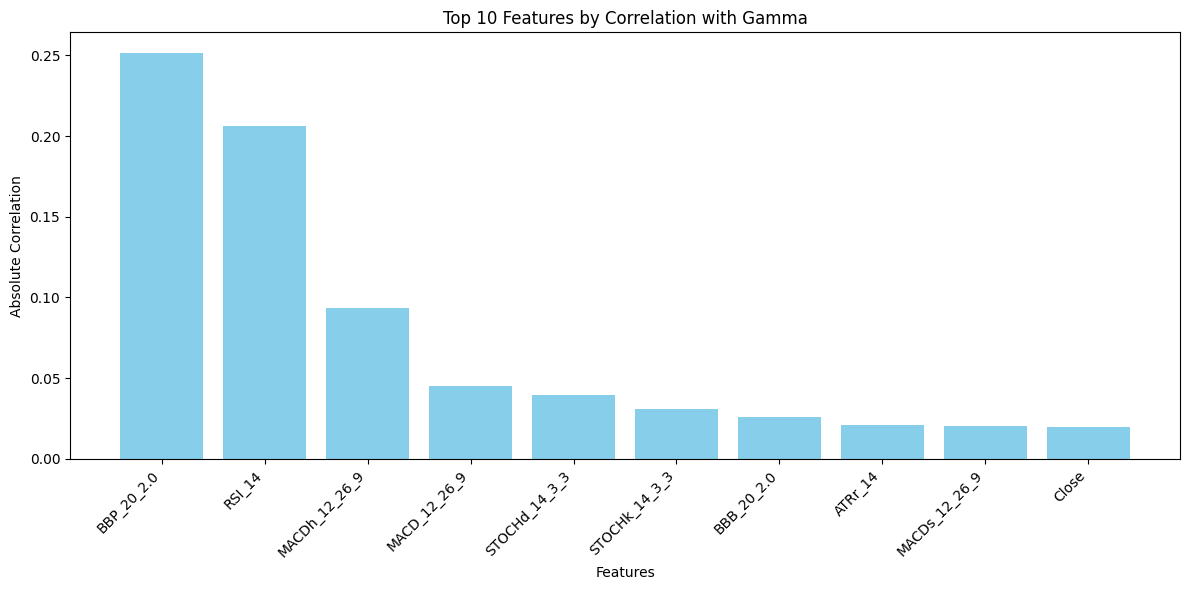

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the Enhanced Data
data = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Calculate Correlation
correlation = data.corr()["Gamma"].abs().sort_values(ascending=False)

# Step 3: Select Top Features
selected_features = correlation.index[1:11]  # Exclude Gamma (target variable)

# Step 4: Create Bar Plot
plt.figure(figsize=(12, 6))
plt.bar(selected_features, correlation[selected_features], color="skyblue")
plt.title("Top 10 Features by Correlation with Gamma")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# Transform the test data
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Step 2: Split the Data
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable (Gamma)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Handle Missing Values
# Impute missing values with the mean
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Step 4: Train the MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),  # Two hidden layers with 50 neurons each
    activation="logistic",         # Logistic activation function
    solver="adam",                # ADAM optimizer
    max_iter=2000,                 # Maximum number of iterations
    random_state=42                # Random seed for reproducibility
)

# Train the model on the training data
mlp.fit(X_train, y_train)

# Step 5: Evaluate the Model
y_pred = mlp.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Generate a classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 56.92%
Classification Report:
              precision    recall  f1-score   support

          -1       0.67      0.43      0.53       281
           1       0.51      0.74      0.60       225

    accuracy                           0.57       506
   macro avg       0.59      0.59      0.57       506
weighted avg       0.60      0.57      0.56       506



In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Split the Data
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable (Gamma)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Handle Missing Values
# Impute missing values with the mean
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Step 4: Scale the Data
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Step 5: Train the MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),  # Two hidden layers with 50 neurons each
    activation="logistic",         # Logistic activation function
    solver="adam",                 # ADAM optimizer
    max_iter=2000,                 # Maximum number of iterations
    random_state=42                # Random seed for reproducibility
)

# Train the model on the training data
mlp.fit(X_train_scaled, y_train)

# Step 6: Evaluate the Model
y_pred = mlp.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Generate the classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the report to a pandas DataFrame
report_df = pd.DataFrame(report).transpose()

# Display the classification report as a table
print("\nClassification Report as Table:")
print(report_df)

Model Accuracy: 62.06%

Classification Report as Table:
              precision    recall  f1-score     support
-1             0.706977  0.540925  0.612903  281.000000
1              0.556701  0.720000  0.627907  225.000000
accuracy       0.620553  0.620553  0.620553    0.620553
macro avg      0.631839  0.630463  0.620405  506.000000
weighted avg   0.640155  0.620553  0.619575  506.000000


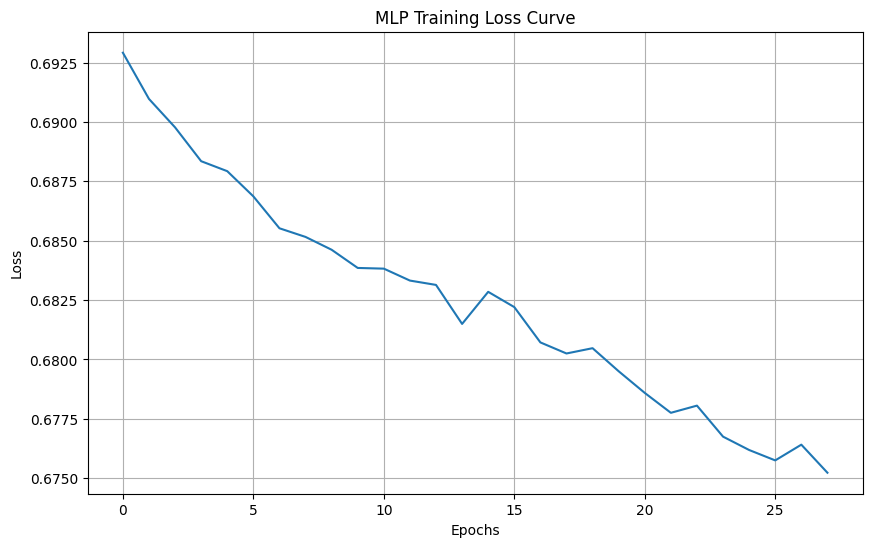

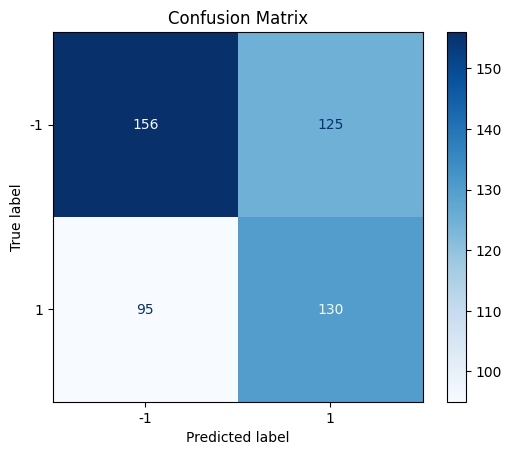

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# Transform the test data
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Step 2: Split the Data
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable (Gamma)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Handle Missing Values
# Impute missing values with the mean
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Step 4: Train the MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    random_state=42,
    early_stopping=True  # Enable early stopping for loss curve
)

mlp.fit(X_train, y_train)

# Step 5: Evaluate the Model
y_pred = mlp.predict(X_test)

# Visualization: Training Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Visualization: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [22]:
# Save the classification report to CSV
report_df.to_csv("classification_report.csv")

Step 3(d).

Implement the cross-fold validation or k-cross-fold validation.

In [23]:
print(data.isnull().sum())

BBP_20_2.0       19
RSI_14           14
MACDh_12_26_9    33
MACD_12_26_9     25
STOCHd_14_3_3    17
STOCHk_14_3_3    15
BBB_20_2.0       19
ATRr_14          14
MACDs_12_26_9    33
Close             0
Gamma             0
dtype: int64


In [24]:
import pandas as pd

# Load the data (assuming the file path is correct)
data = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Calculate the number of missing values per column
missing_values = data.isnull().sum()

# Convert the results into a DataFrame for a more structured table
missing_values_df = pd.DataFrame(missing_values, columns=["Missing Values"])

# Display the table
print("Missing Values Table:")
print(missing_values_df)

Missing Values Table:
               Missing Values
Close                       0
High                        0
Low                         0
Open                        0
Volume                      0
Gamma                       0
RSI_14                     14
SMA_20                     19
EMA_20                     19
BBL_20_2.0                 19
BBM_20_2.0                 19
BBU_20_2.0                 19
BBB_20_2.0                 19
BBP_20_2.0                 19
MACD_12_26_9               25
MACDh_12_26_9              33
MACDs_12_26_9              33
OBV                         0
STOCHk_14_3_3              15
STOCHd_14_3_3              17
ATRr_14                    14


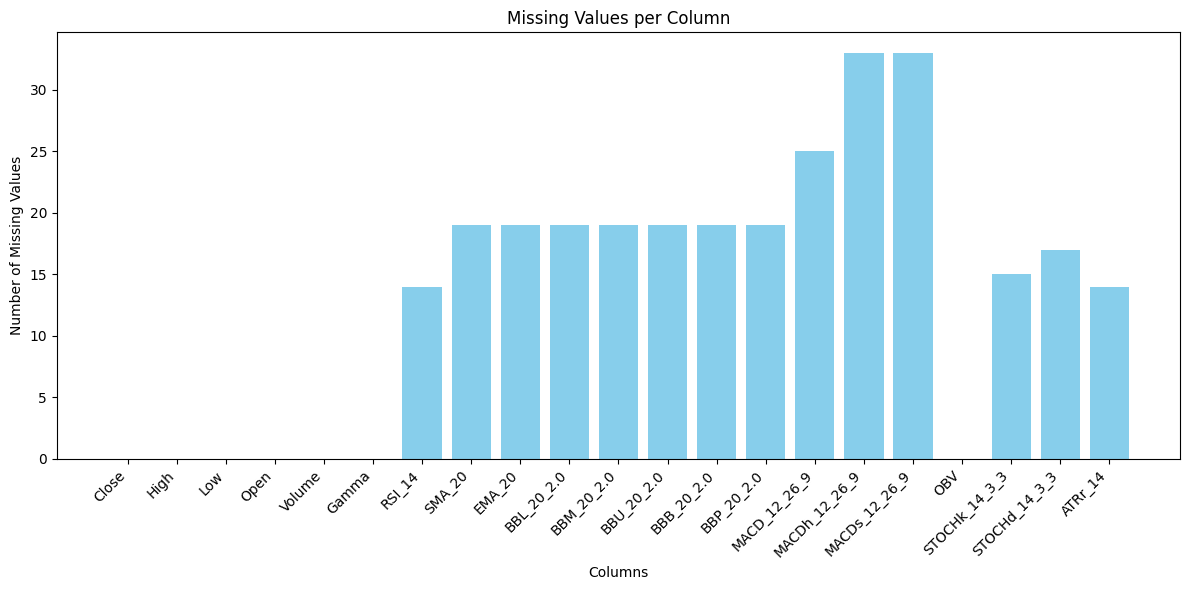

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv("ECH_data_with_indicators.csv", parse_dates=["Date"], index_col="Date")

# Calculate missing values and create DataFrame
missing_values = data.isnull().sum()
missing_values_df = pd.DataFrame(missing_values, columns=["Missing Values"])

# Create the bar plot
plt.figure(figsize=(12, 6))
plt.bar(missing_values_df.index, missing_values_df["Missing Values"], color="skyblue")
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Impute Missing Values
imputer = SimpleImputer(strategy="mean")
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns, index=data.index)

# Step 3: Define the MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    random_state=42
)

# Use Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Perform 10-Fold Cross-Validation
X = data_imputed.drop(columns=["Gamma"])  # Features
y = data_imputed["Gamma"]                # Target

cv_scores = cross_val_score(mlp, X, y, cv=10, scoring="accuracy")

# Step 5: Calculate Average Accuracy
average_accuracy = cv_scores.mean()
print(f"10-Fold Cross-Validation Accuracy: {average_accuracy * 100:.2f}%")

# Print the accuracy for each fold
print("\nAccuracy for Each Fold:")
for i, score in enumerate(cv_scores):
    print(f"Fold {i + 1}: {score * 100:.2f}%")

10-Fold Cross-Validation Accuracy: 58.01%

Accuracy for Each Fold:
Fold 1: 63.64%
Fold 2: 59.29%
Fold 3: 54.55%
Fold 4: 62.45%
Fold 5: 58.89%
Fold 6: 57.31%
Fold 7: 49.80%
Fold 8: 60.47%
Fold 9: 53.75%
Fold 10: 59.92%


In [27]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Impute Missing Values
imputer = SimpleImputer(strategy="mean")
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns, index=data.index)

# Step 3: Define the MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    random_state=42
)

# Step 4: Perform 10-Fold Cross-Validation
X = data_imputed.drop(columns=["Gamma"])  # Features
y = data_imputed["Gamma"]                # Target

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cv_scores = cross_val_score(mlp, X_scaled, y, cv=10, scoring="accuracy")

# Step 5: Create a Table with the Results
results_table = pd.DataFrame({
    "Fold": [f"Fold {i + 1}" for i in range(len(cv_scores))],
    "Accuracy (%)": [score * 100 for score in cv_scores]
})

# Add the average accuracy to the table
average_row = pd.DataFrame([{"Fold": "Average", "Accuracy (%)": cv_scores.mean() * 100}])
results_table = pd.concat([results_table, average_row], ignore_index=True)

# Display the table
print("10-Fold Cross-Validation Results:")
print(results_table)

10-Fold Cross-Validation Results:
       Fold  Accuracy (%)
0    Fold 1     63.636364
1    Fold 2     60.869565
2    Fold 3     56.521739
3    Fold 4     69.960474
4    Fold 5     63.241107
5    Fold 6     62.055336
6    Fold 7     62.055336
7    Fold 8     63.636364
8    Fold 9     62.845850
9   Fold 10     64.285714
10  Average     62.910785


10-Fold Cross-Validation Results:
       Fold  Accuracy (%)
0    Fold 1     63.636364
1    Fold 2     60.869565
2    Fold 3     56.521739
3    Fold 4     69.960474
4    Fold 5     63.241107
5    Fold 6     62.055336
6    Fold 7     62.055336
7    Fold 8     63.636364
8    Fold 9     62.845850
9   Fold 10     64.285714
10  Average     62.910785


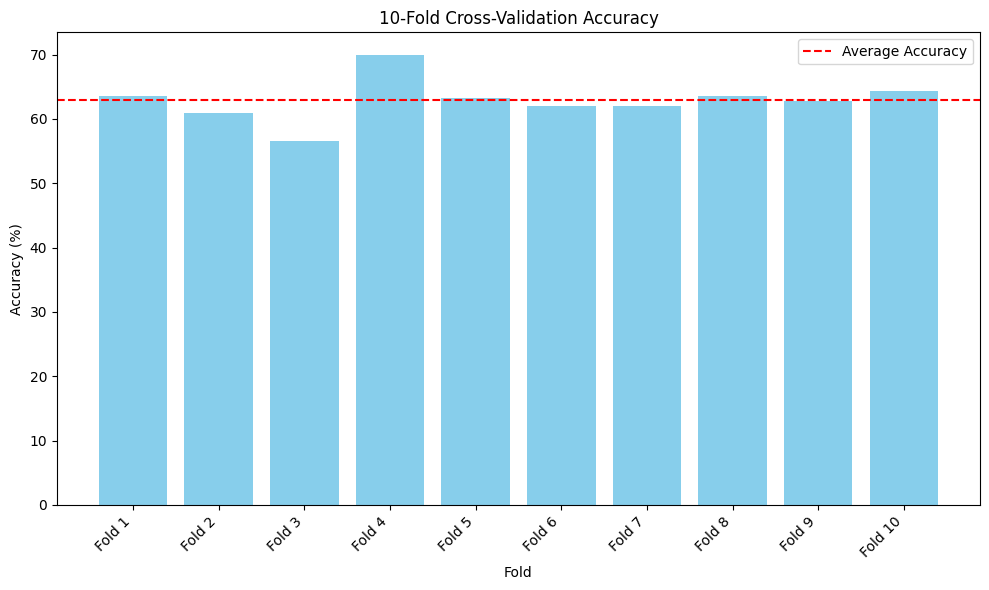

In [28]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Impute Missing Values
imputer = SimpleImputer(strategy="mean")
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns, index=data.index)

# Step 3: Define the MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    random_state=42
)

# Step 4: Perform 10-Fold Cross-Validation
X = data_imputed.drop(columns=["Gamma"])  # Features
y = data_imputed["Gamma"]                # Target

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cv_scores = cross_val_score(mlp, X_scaled, y, cv=10, scoring="accuracy")

# Step 5: Create a Table with the Results
results_table = pd.DataFrame({
    "Fold": [f"Fold {i + 1}" for i in range(len(cv_scores))],
    "Accuracy (%)": [score * 100 for score in cv_scores]
})

# Add the average accuracy to the table
average_row = pd.DataFrame([{"Fold": "Average", "Accuracy (%)": cv_scores.mean() * 100}])
results_table = pd.concat([results_table, average_row], ignore_index=True)

# Display the table
print("10-Fold Cross-Validation Results:")
print(results_table)

# Visualization: Cross-Validation Accuracy
plt.figure(figsize=(10, 6))
plt.bar(results_table["Fold"][:-1], results_table["Accuracy (%)"][:-1], color="skyblue")  # Exclude average row
# Access the average accuracy using .iloc[-1] to get the last row
plt.axhline(y=results_table["Accuracy (%)"].iloc[-1], color="red", linestyle="--", label="Average Accuracy")  # Average line
plt.title("10-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
import joblib
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Handle Missing Values
imputer = SimpleImputer(strategy="mean")  # Create an imputer instance
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Step 3: Train the Final Model
# Define features (X) and target variable (y)
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable (Gamma)

# Handle Missing Values before training
imputer = SimpleImputer(strategy="mean") # Create an imputer instance
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns) # Impute missing values in X

# Initialize the final_mlp model before fitting
final_mlp = MLPClassifier(hidden_layer_sizes=(50, 50),
                          activation="logistic",
                          solver="adam",
                          max_iter=2000,
                          random_state=42) # Initialize final_mlp

# Train the final model on the entire dataset
final_mlp.fit(X, y)

# Step 4: Save the Final Model
# Save the trained model to a file for future use
model_filename = "final_mlp_model.pkl"
joblib.dump(final_mlp, model_filename)
print(f"Final model saved to {model_filename}")

Final model saved to final_mlp_model.pkl


In [32]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Handle Missing Values
imputer = SimpleImputer(strategy="mean")  # Create an imputer instance
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Step 3: Scale the Features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

# Step 4: Train the Final Model
final_mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    random_state=42
)
final_mlp.fit(X_scaled, y)

# Step 5: Save the Final Model
model_filename = "final_mlp_model.pkl"
joblib.dump(final_mlp, model_filename)

# Display a message
print(f"Final model saved to {model_filename}")

# Step 6: Create a Summary Table
steps = [
    {"Step": "Load Data", "Description": "Loaded dataset from ECH_selected_features_correlation.csv"},
    {"Step": "Handle Missing Values", "Description": "Imputed missing values using the mean strategy"},
    {"Step": "Scale Features", "Description": "Scaled features using StandardScaler"},
    {"Step": "Train Model", "Description": "Trained MLPClassifier with two hidden layers of 50 neurons each"},
    {"Step": "Save Model", "Description": f"Saved model as {model_filename}"}
]

summary_table = pd.DataFrame(steps)

# Print the summary table
print("\nSummary of Workflow:")
print(summary_table)

Final model saved to final_mlp_model.pkl

Summary of Workflow:
                    Step                                        Description
0              Load Data  Loaded dataset from ECH_selected_features_corr...
1  Handle Missing Values     Imputed missing values using the mean strategy
2         Scale Features               Scaled features using StandardScaler
3            Train Model  Trained MLPClassifier with two hidden layers o...
4             Save Model                 Saved model as final_mlp_model.pkl


Final model saved to final_mlp_model.pkl

Summary of Workflow:
                    Step                                        Description
0              Load Data  Loaded dataset from ECH_selected_features_corr...
1  Handle Missing Values     Imputed missing values using the mean strategy
2         Scale Features               Scaled features using StandardScaler
3            Train Model  Trained MLPClassifier with two hidden layers o...
4             Save Model                 Saved model as final_mlp_model.pkl


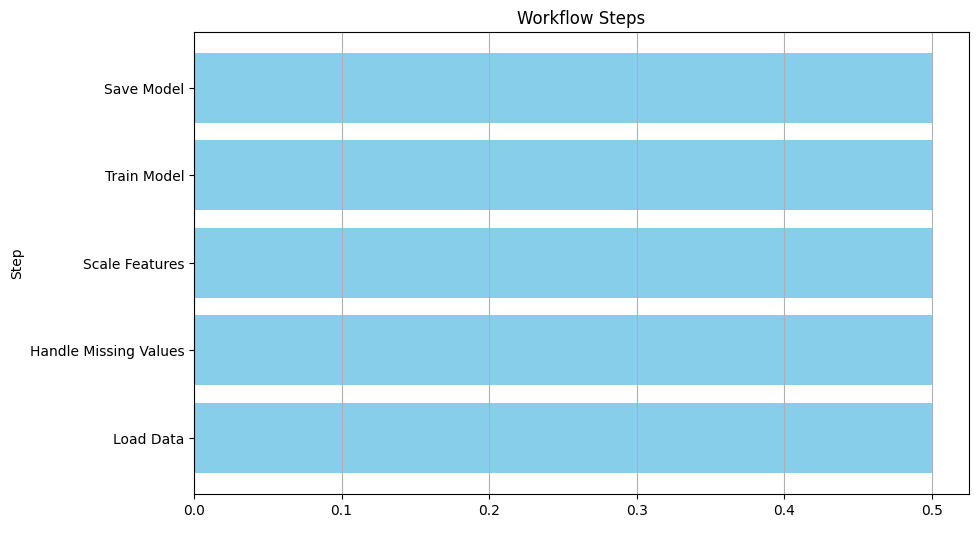

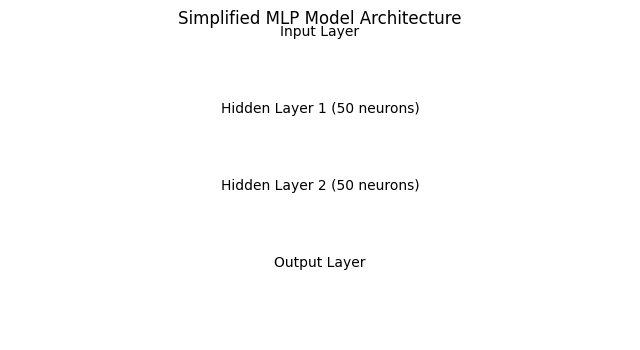

In [33]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Handle Missing Values
imputer = SimpleImputer(strategy="mean")  # Create an imputer instance
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Step 3: Scale the Features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

# Step 4: Train the Final Model
final_mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    random_state=42
)
final_mlp.fit(X_scaled, y)

# Step 5: Save the Final Model
model_filename = "final_mlp_model.pkl"
joblib.dump(final_mlp, model_filename)

# Display a message
print(f"Final model saved to {model_filename}")

# Step 6: Create a Summary Table
steps = [
    {"Step": "Load Data", "Description": "Loaded dataset from ECH_selected_features_correlation.csv"},
    {"Step": "Handle Missing Values", "Description": "Imputed missing values using the mean strategy"},
    {"Step": "Scale Features", "Description": "Scaled features using StandardScaler"},
    {"Step": "Train Model", "Description": "Trained MLPClassifier with two hidden layers of 50 neurons each"},
    {"Step": "Save Model", "Description": f"Saved model as {model_filename}"}
]

summary_table = pd.DataFrame(steps)

# Print the summary table
print("\nSummary of Workflow:")
print(summary_table)

# --- Visualization ---

# 1. Workflow Diagram (using matplotlib)
plt.figure(figsize=(10, 6))
plt.barh(summary_table["Step"], width=0.5, color="skyblue")  # Horizontal bar chart
plt.title("Workflow Steps")
plt.xlabel(" ")  # Hide x-axis label
plt.ylabel("Step")
plt.grid(axis="x")
plt.show()

# 2. Model Architecture Diagram (using matplotlib - simplified)
plt.figure(figsize=(8, 4))
plt.title("Simplified MLP Model Architecture")
layers = ["Input Layer", "Hidden Layer 1 (50 neurons)", "Hidden Layer 2 (50 neurons)", "Output Layer"]
for i, layer in enumerate(layers):
    plt.text(0.5, 1 - i / len(layers), layer, ha="center", va="center", fontsize=10)
plt.axis("off")  # Hide axes
plt.show()

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import joblib
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Load the Final Model
model_filename = "final_mlp_model.pkl"
final_mlp = joblib.load(model_filename)
print(f"Final model loaded from {model_filename}")

# Step 3: Evaluate on a Separate Test Set
# Define features (X) and target variable (y)
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable (Gamma)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle missing values in X_test using the same imputer fitted on the training data
imputer = SimpleImputer(strategy="mean") # Create an imputer instance if not already created
X_test = pd.DataFrame(imputer.fit_transform(X_test), columns=X_test.columns)  # Impute missing values in X_test

# Make predictions on the test set
y_pred = final_mlp.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy * 100:.2f}%")

# Generate a classification report
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred))

# Step 4: Evaluate Using Cross-Validation
# Perform 10-fold cross-validation
# Handle missing values in X before cross-validation
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)  # Impute missing values in X
cv_scores = cross_val_score(final_mlp, X, y, cv=10, scoring="accuracy")

# Calculate average accuracy
average_accuracy = cv_scores.mean()
print(f"10-Fold Cross-Validation Accuracy: {average_accuracy * 100:.2f}%")

# Print the accuracy for each fold
print("\nAccuracy for Each Fold:")
for i, score in enumerate(cv_scores):
    print(f"Fold {i + 1}: {score * 100:.2f}%")

Final model loaded from final_mlp_model.pkl
Test Set Accuracy: 47.04%
Test Set Classification Report:
              precision    recall  f1-score   support

          -1       0.64      0.10      0.18       281
           1       0.45      0.93      0.61       225

    accuracy                           0.47       506
   macro avg       0.55      0.52      0.39       506
weighted avg       0.56      0.47      0.37       506

10-Fold Cross-Validation Accuracy: 58.01%

Accuracy for Each Fold:
Fold 1: 63.64%
Fold 2: 59.29%
Fold 3: 54.55%
Fold 4: 62.45%
Fold 5: 58.89%
Fold 6: 57.31%
Fold 7: 49.80%
Fold 8: 60.47%
Fold 9: 53.75%
Fold 10: 59.92%


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import joblib
from sklearn.impute import SimpleImputer

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Load the Final Model
model_filename = "final_mlp_model.pkl"
final_mlp = joblib.load(model_filename)
print(f"Final model loaded from {model_filename}")

# Step 3: Evaluate on a Separate Test Set
# Define features (X) and target variable (y)
X = data.drop(columns=["Gamma"])  # Features (all columns except Gamma)
y = data["Gamma"]  # Target variable (Gamma)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle missing values in X_test using the same imputer fitted on the training data
imputer = SimpleImputer(strategy="mean")  # Create an imputer instance if not already created
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Make predictions on the test set
y_pred = final_mlp.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_accuracy * 100:.2f}%")

# Generate a classification report
classification_rep = classification_report(y_test, y_pred, output_dict=True)

# Step 4: Evaluate Using Cross-Validation
# Perform 10-fold cross-validation
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)  # Impute missing values in X
cv_scores = cross_val_score(final_mlp, X, y, cv=10, scoring="accuracy")

# Create a Table of Results
results_table = pd.DataFrame({
    "Metric": ["Test Set Accuracy"] + [f"Fold {i + 1} Accuracy" for i in range(len(cv_scores))] + ["Average CV Accuracy"],
    "Value (%)": [test_accuracy * 100] + [score * 100 for score in cv_scores] + [cv_scores.mean() * 100]
})

# Display the Table
print("\nPerformance Summary:")
print(results_table)

Final model loaded from final_mlp_model.pkl
Test Set Accuracy: 47.04%

Performance Summary:
                 Metric  Value (%)
0     Test Set Accuracy  47.035573
1       Fold 1 Accuracy  63.636364
2       Fold 2 Accuracy  59.288538
3       Fold 3 Accuracy  54.545455
4       Fold 4 Accuracy  62.450593
5       Fold 5 Accuracy  58.893281
6       Fold 6 Accuracy  57.312253
7       Fold 7 Accuracy  49.802372
8       Fold 8 Accuracy  60.474308
9       Fold 9 Accuracy  53.754941
10     Fold 10 Accuracy  59.920635
11  Average CV Accuracy  58.007874


Final model loaded from final_mlp_model.pkl
Test Set Accuracy: 47.04%
Test Set Classification Report:
              precision    recall  f1-score   support

          -1       0.64      0.10      0.18       281
           1       0.45      0.93      0.61       225

    accuracy                           0.47       506
   macro avg       0.55      0.52      0.39       506
weighted avg       0.56      0.47      0.37       506



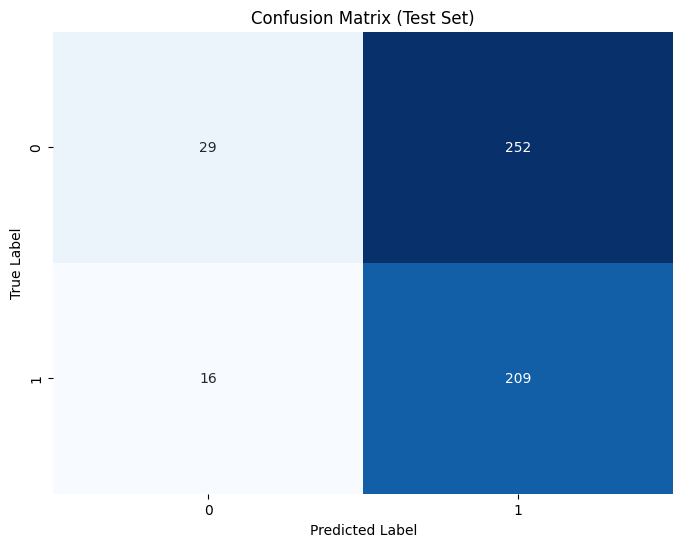

10-Fold Cross-Validation Accuracy: 58.01%


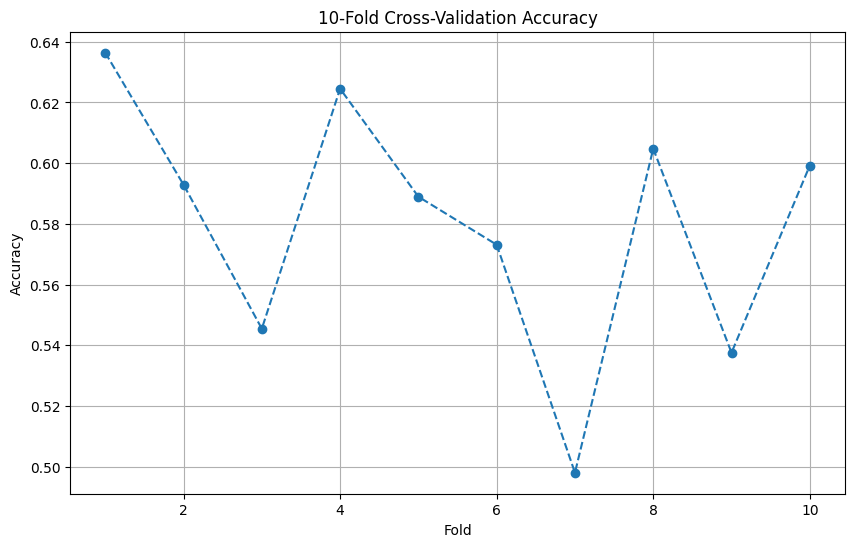

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the Selected Features
data = pd.read_csv("ECH_selected_features_correlation.csv", parse_dates=["Date"], index_col="Date")

# Step 2: Load the Final Model
model_filename = "final_mlp_model.pkl"
final_mlp = joblib.load(model_filename)
print(f"Final model loaded from {model_filename}")

# Step 3: Evaluate on a Separate Test Set
X = data.drop(columns=["Gamma"])
y = data["Gamma"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy="mean")
X_test = pd.DataFrame(imputer.fit_transform(X_test), columns=X_test.columns)

y_pred = final_mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy * 100:.2f}%")
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred))

# Visualization 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Step 4: Evaluate Using Cross-Validation
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
cv_scores = cross_val_score(final_mlp, X, y, cv=10, scoring="accuracy")
average_accuracy = cv_scores.mean()
print(f"10-Fold Cross-Validation Accuracy: {average_accuracy * 100:.2f}%")

# Visualization 2: Cross-Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cv_scores, marker="o", linestyle="--")
plt.title("10-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [37]:
import joblib

# Save the final model to a file
model_filename = "final_mlp_model.pkl"
joblib.dump(final_mlp, model_filename)
print(f"Final model saved to {model_filename}")

Final model saved to final_mlp_model.pkl


In [42]:
!python app.py

 * Serving Flask app 'app'
 * Debug mode: on
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat
 * Debugger is active!
 * Debugger PIN: 700-858-851
